In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pathlib

In [2]:
# Dataset path
DATASET_PATH = pathlib.Path(
    r"D:\PROJECTS\ML_projects\FOD_Project\dataset_grayscale"
)

# Image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Number of classes
NUM_CLASSES = 5

# Random seed
SEED = 42

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "train",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "test",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

Found 1960 files belonging to 5 classes.
Found 401 files belonging to 5 classes.
Found 441 files belonging to 5 classes.


In [4]:
class_names = train_ds.class_names

print("Classes:")
print(class_names)

Classes:
['battery', 'fuelcap', 'pliers', 'screwdrivers', 'sodacan']


In [5]:
for images, labels in train_ds.take(1):
    print("Image batch shape :", images.shape)
    print("Label batch shape :", labels.shape)

Image batch shape : (32, 128, 128, 1)
Label batch shape : (32,)


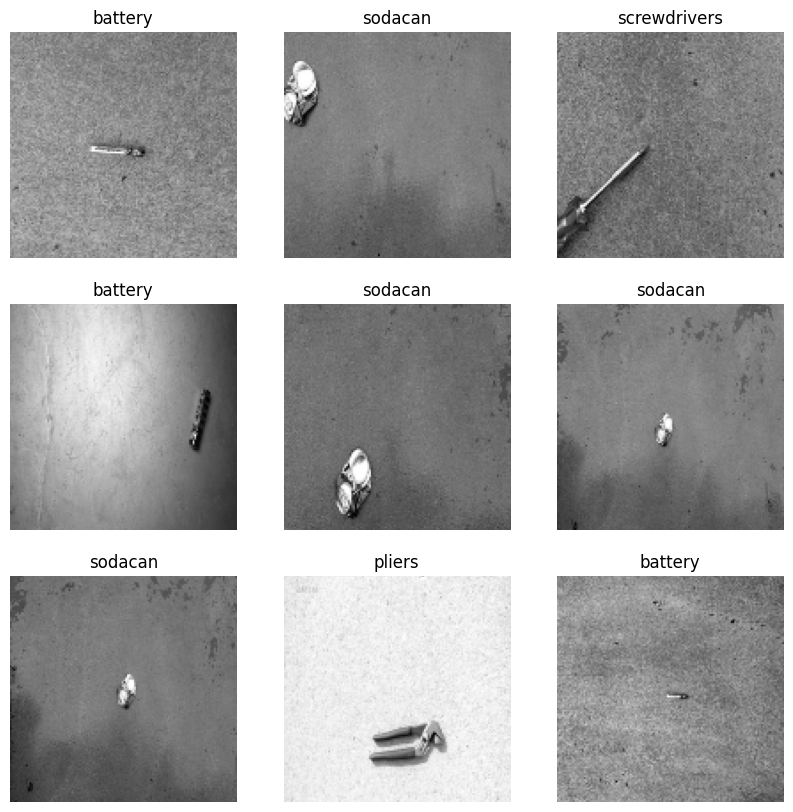

In [6]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [7]:
#optimize pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [8]:
# data augmentaion
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.10),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomZoom(0.10)
])

In [9]:
#CNN model
model = keras.Sequential([

    layers.Input(shape=(128, 128, 1)),

    # Data augmentation
    #data_augmentation,

    # Normalize pixel values (0-255 → 0-1)
    layers.Rescaling(1./255),

    # --------------------------
    # Feature Extraction
    # --------------------------

    layers.Conv2D(
        filters=16,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D(),

    # --------------------------
    # Classification
    # --------------------------

    layers.GlobalAveragePooling2D(),

    layers.Dense(32, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(5, activation='softmax')

    ])

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,541 (99.77 KB)

 Trainable params: 25,541 (99.77 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
#early_stop = tf.keras.callbacks.EarlyStopping(
#    monitor='val_loss',
#    patience=5,
#    restore_best_weights=True
#)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    #callbacks=[early_stop]
)

Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.3102 - loss: 1.4852 - val_accuracy: 0.3242 - val_loss: 1.4247
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4332 - loss: 1.3206 - val_accuracy: 0.5411 - val_loss: 1.0620
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7056 - loss: 0.8428 - val_accuracy: 0.6234 - val_loss: 0.8859
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7204 - loss: 0.7552 - val_accuracy: 0.5312 - val_loss: 0.9437
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7194 - loss: 0.7157 - val_accuracy: 0.5985 - val_loss: 0.8905
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7418 - loss: 0.6762 - val_accuracy: 0.5860 - val_loss: 0.9103
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7903 - loss: 0.5901 - val_accuracy: 0.4289 - val_loss: 1.0938
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7872 - loss: 0.5668 - val_accuracy: 0.6359 - v

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred = model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

print(confusion_matrix(y_true, y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

     battery       0.24      0.91      0.38        53
     fuelcap       1.00      0.82      0.90        38
      pliers       1.00      1.00      1.00       126
screwdrivers       0.86      0.77      0.82        97
     sodacan       0.00      0.00      0.00       127

    accuracy                           0.63       441
   macro avg       0.62      0.70      0.62       441
weighted avg       0.59      0.63      0.59       441

[[ 48   0   0   5   0]
 [  0  31   0   7   0]
 [  0   0 126   0   0]
 [ 22   0   0  75   0]
 [127   0   0   0   0]]


D:\PROJECTS\ML_projects\FOD_Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\PROJECTS\ML_projects\FOD_Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\PROJECTS\ML_projects\FOD_Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is